# Laboratório 08 TSNE Vinicius Cordeiro

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
import seaborn as sns

Gerando dataset sintético

In [3]:
n_samples = 300
n_features = 20
n_clusters = 5

X, y = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=n_clusters,
    random_state=42,
    cluster_std=5.0
)

print("Formato do dataset X:", X.shape)
print("Formato do vetor y:", y.shape)

Formato do dataset X: (300, 20)
Formato do vetor y: (300,)


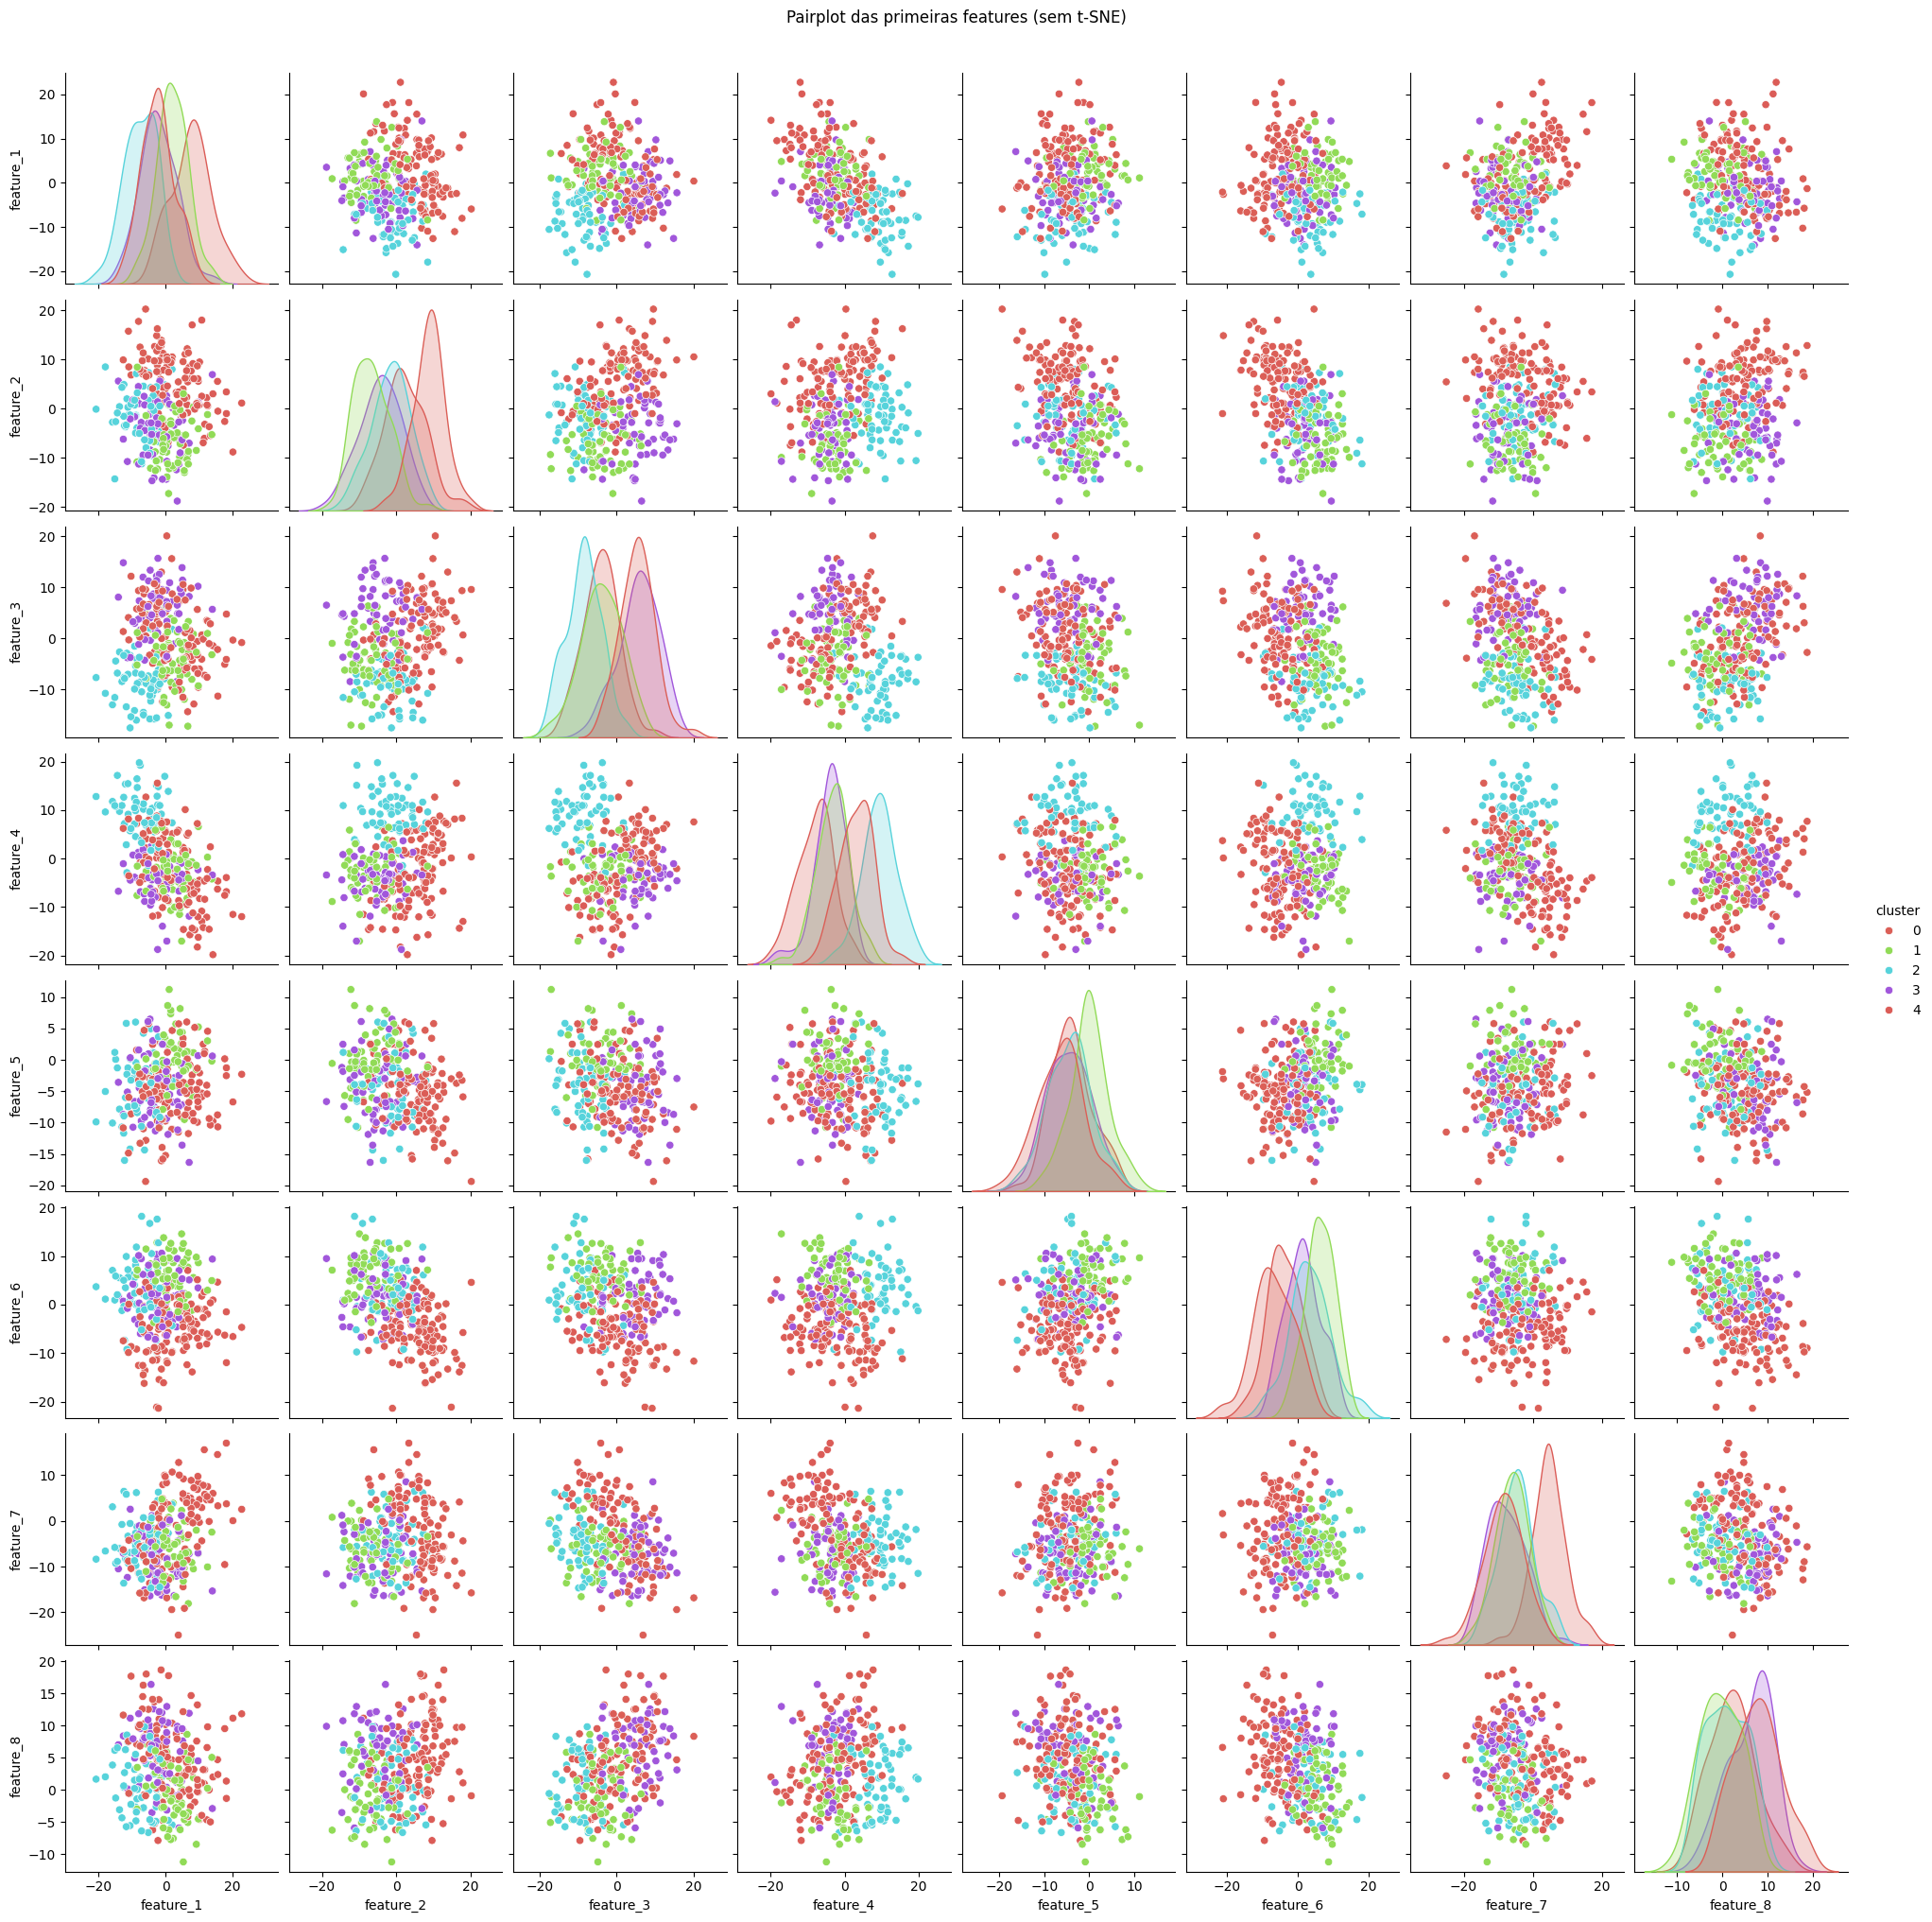

In [4]:
df = pd.DataFrame(X[:, :8], columns=[f'feature_{i+1}' for i in range(8)])
df['cluster'] = y

sns.pairplot(df, hue='cluster', palette='hls')
plt.suptitle("Pairplot das primeiras features (sem t-SNE)", y=1.02)
plt.show()

# Implementação da Classe t-SNE

In [2]:
class TSNE:
    def __init__(self, n_components=2, perplexity=30.0, lr=200.0, n_iter=500):
        # Número de dimensões finais, perplexidade, taxa de aprendizado e iterações
        self.n_components = n_components
        self.perplexity = perplexity
        self.lr = lr
        self.n_iter = n_iter

    # -------------------------------------------------------
    # 1. Calcula matriz de distâncias euclidianas ao quadrado
    # -------------------------------------------------------
    def _distances(self, X):
        sum_X = np.sum(X**2, axis=1)
        return np.add(np.add(-2 * X @ X.T, sum_X).T, sum_X)

    # -------------------------------------------------------------------------
    # 2. Calcula a matriz P (probabilidades no espaço de alta dimensão)
    #    Cada linha P[i] é ajustada para ter uma entropia que corresponda à perplexidade
    # -------------------------------------------------------------------------
    def _p_matrix(self, D):
        n = D.shape[0]
        P = np.zeros((n, n))
        logU = np.log2(self.perplexity)

        for i in range(n):
            beta = 1.0  # inverso da variância (1 / (2*sigma²))
            Di = np.delete(D[i], i)  # remove a distância com ele mesmo

            # Ajuste de beta por busca simples até alcançar a perplexidade desejada
            for _ in range(30):
                P_i = np.exp(-Di * beta)
                P_i /= np.sum(P_i)
                H = -np.sum(P_i * np.log2(P_i + 1e-12))  # entropia
                if abs(H - logU) < 1e-3:  # se já está próximo, para
                    break
                beta *= 1.2 if H > logU else 0.8  # ajusta beta

            P[i, np.arange(n) != i] = P_i

        # Simetriza e normaliza
        P = (P + P.T) / (2 * n)
        return np.maximum(P, 1e-12)

    # -------------------------------------------------------
    # 3. Executa o t-SNE e retorna o embedding 2D
    # -------------------------------------------------------
    def fit_transform(self, X):
        n = X.shape[0]

        # Calcula afinidades no espaço original (P)
        D = self._distances(X)
        P = self._p_matrix(D)

        # Inicializa o embedding aleatoriamente
        Y = np.random.randn(n, self.n_components)

        # Loop de otimização
        for it in range(self.n_iter):
            # Calcula afinidades no espaço de baixa dimensão (Q)
            sum_Y = np.sum(Y**2, axis=1)
            num = 1 / (1 + np.add(np.add(-2 * Y @ Y.T, sum_Y).T, sum_Y))
            np.fill_diagonal(num, 0)
            Q = np.maximum(num / np.sum(num), 1e-12)

            # Calcula o gradiente
            PQ = P - Q
            for i in range(n):
                # Soma ponderada das diferenças (força de atração/repulsão)
                dY_i = np.sum((PQ[:, i] * num[:, i])[:, None] * (Y[i] - Y), axis=0)
                Y[i] -= self.lr * dY_i  # Atualiza posição

            # Centraliza os pontos
            Y -= np.mean(Y, axis=0)

            # Mostra custo a cada 100 iterações
            if (it + 1) % 100 == 0:
                cost = np.sum(P * np.log(P / Q))
                print(f"Iter {it+1:4d}: cost = {cost:.4f}")

        return Y

aplicando a TSNE

In [5]:
custom_tsne = TSNE(n_components=2, perplexity=30.0, n_iter=1000, lr=200)
X_embedded_custom = custom_tsne.fit_transform(X)

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 0.7637
Iter  200: cost = 0.6651
Iter  300: cost = 0.6224
Iter  400: cost = 0.6033
Iter  500: cost = 0.5910
Iter  600: cost = 0.5822
Iter  700: cost = 0.5754
Iter  800: cost = 0.5699
Iter  900: cost = 0.5655
Iter 1000: cost = 0.5611


vizualisando o resultado da implementação

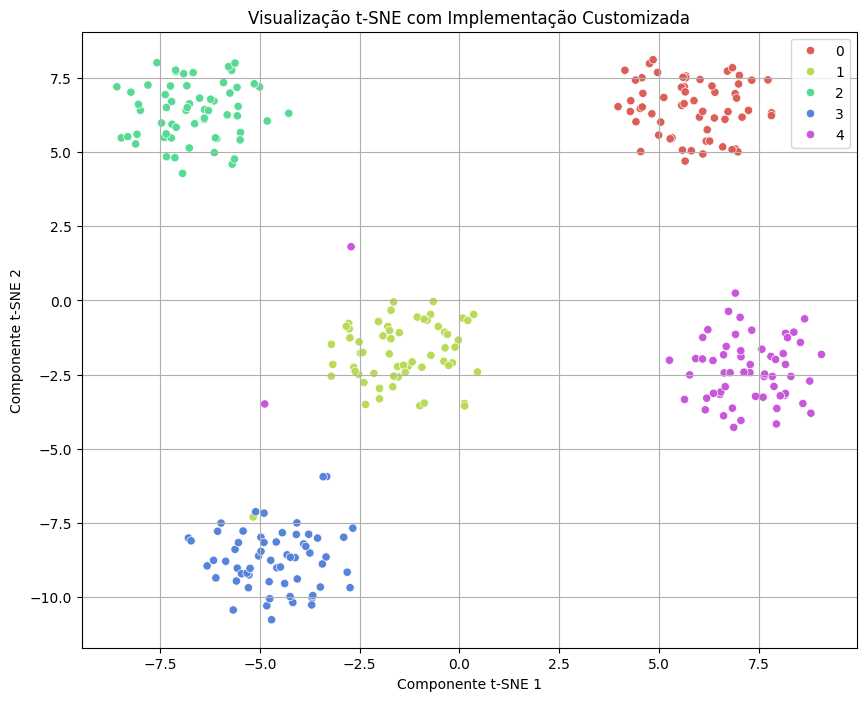

In [6]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_embedded_custom[:, 0],
    y=X_embedded_custom[:, 1],
    hue=y,
    palette=sns.color_palette("hls", n_clusters),
    legend="full"
)
plt.title('Visualização t-SNE com Implementação Customizada')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

Exercícios:

Exercício 1

Treine diferentes modelos t-SNE em 2D com diferentes valores de perplexidade para o dataset sintético e plote cada um deles.

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 1.4964
Iter  200: cost = 1.2960
Iter  300: cost = 1.2072
Iter  400: cost = 1.1445
Iter  500: cost = 1.1098
Iter  600: cost = 1.0839
Iter  700: cost = 1.0632
Iter  800: cost = 1.0455
Iter  900: cost = 1.0297
Iter 1000: cost = 1.0142


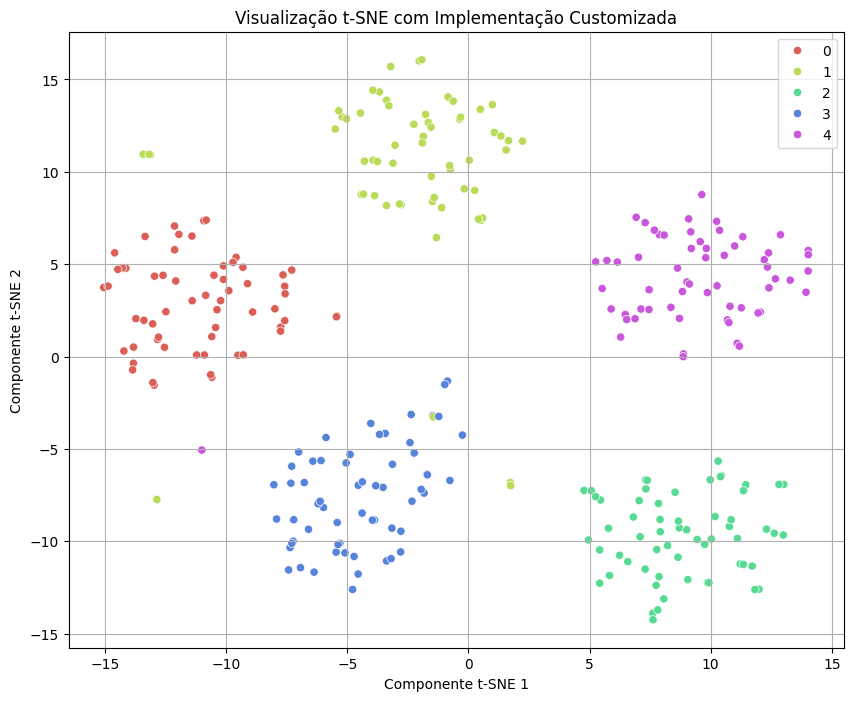

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 1.5548
Iter  200: cost = 1.3350
Iter  300: cost = 1.2416
Iter  400: cost = 1.1776
Iter  500: cost = 1.1422
Iter  600: cost = 1.1162
Iter  700: cost = 1.0961
Iter  800: cost = 1.0797
Iter  900: cost = 1.0660
Iter 1000: cost = 1.0544


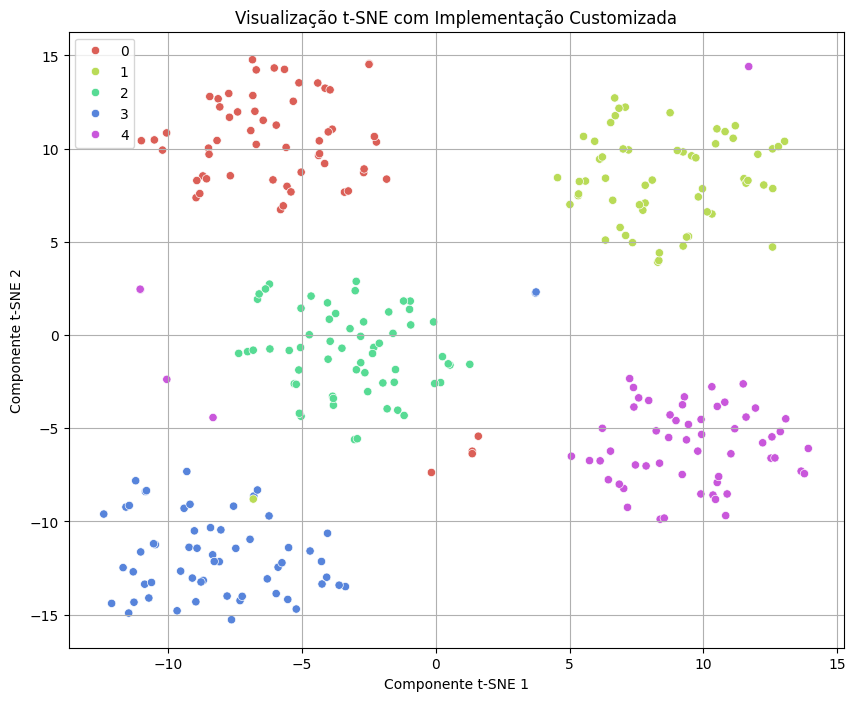

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 1.5769
Iter  200: cost = 1.3011
Iter  300: cost = 1.1952
Iter  400: cost = 1.1303
Iter  500: cost = 1.0858
Iter  600: cost = 1.0512
Iter  700: cost = 1.0273
Iter  800: cost = 1.0064
Iter  900: cost = 0.9896
Iter 1000: cost = 0.9768


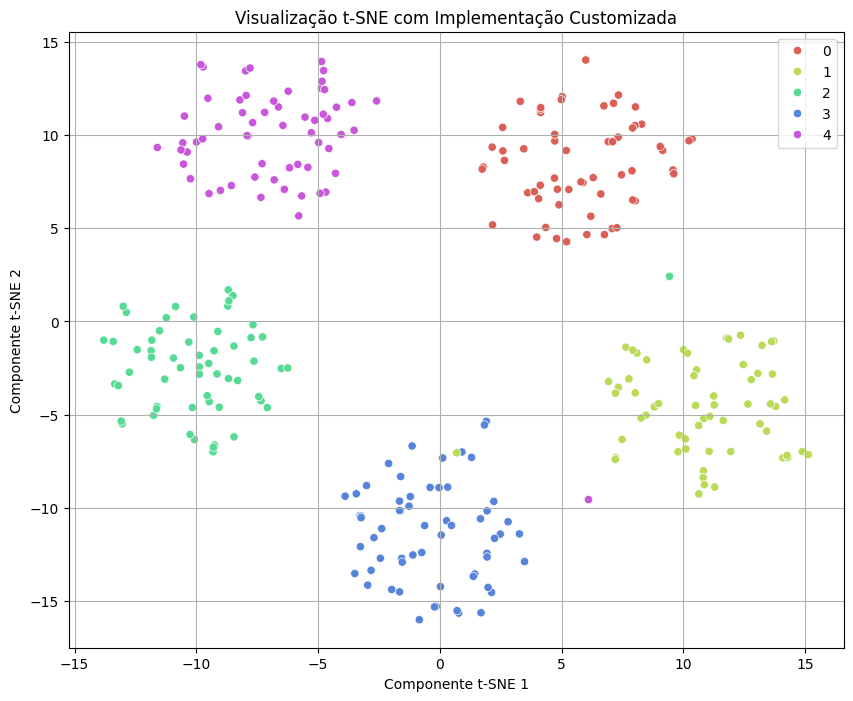

In [7]:
perplexi = [10.0, 30.0, 50.0]
for i in perplexi:
    custom_tsne = TSNE(n_components=2, perplexity=10.0, n_iter=1000, lr=200)
    X_embedded_custom = custom_tsne.fit_transform(X)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_embedded_custom[:, 0],
        y=X_embedded_custom[:, 1],
        hue=y,
        palette=sns.color_palette("hls", n_clusters),
        legend="full"
    )
    plt.title('Visualização t-SNE com Implementação Customizada')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')
    plt.grid(True)
    plt.show()

Exercício 2

Faça um treinamento de um modelo t-SNE para o Dataset Wine. Em seguida, plote o resultado em duas dimensões.

Carregando o Dataset Wine

In [9]:
from sklearn.datasets import load_wine
wines = load_wine()
X = wines.data
y = wines.target

Aplicando a TSNE

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 0.6418
Iter  200: cost = 0.5249
Iter  300: cost = 0.4758
Iter  400: cost = 0.4463
Iter  500: cost = 0.4253
Iter  600: cost = 0.4086
Iter  700: cost = 0.3938
Iter  800: cost = 0.3795
Iter  900: cost = 0.3646
Iter 1000: cost = 0.3544


/tmp/ipython-input-1483925130.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


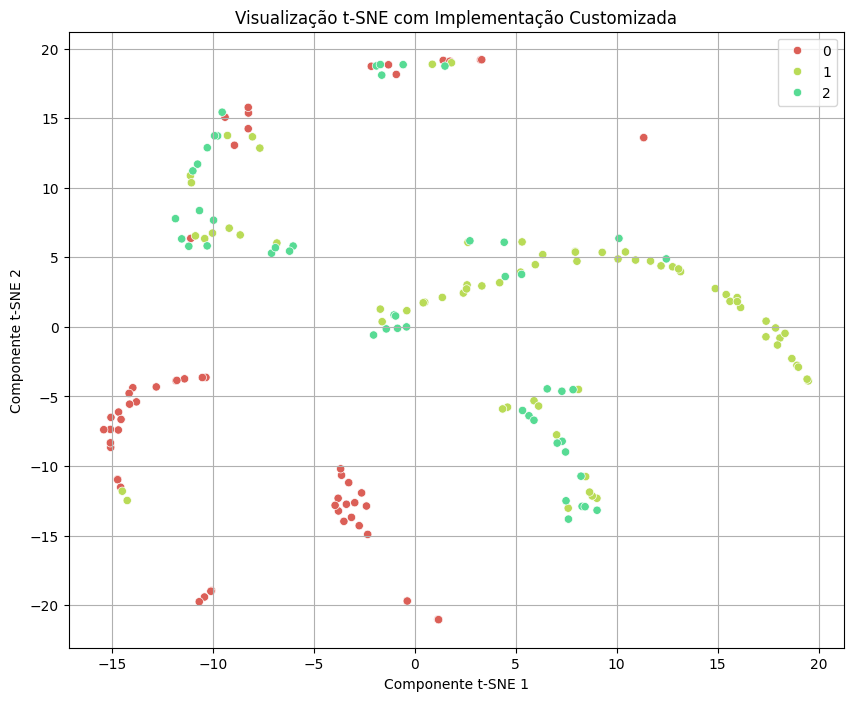

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 0.7672
Iter  200: cost = 0.6391
Iter  300: cost = 0.5846
Iter  400: cost = 0.5537
Iter  500: cost = 0.5323
Iter  600: cost = 0.5120
Iter  700: cost = 0.4774
Iter  800: cost = 0.4674
Iter  900: cost = 0.4595
Iter 1000: cost = 0.4519


/tmp/ipython-input-1483925130.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


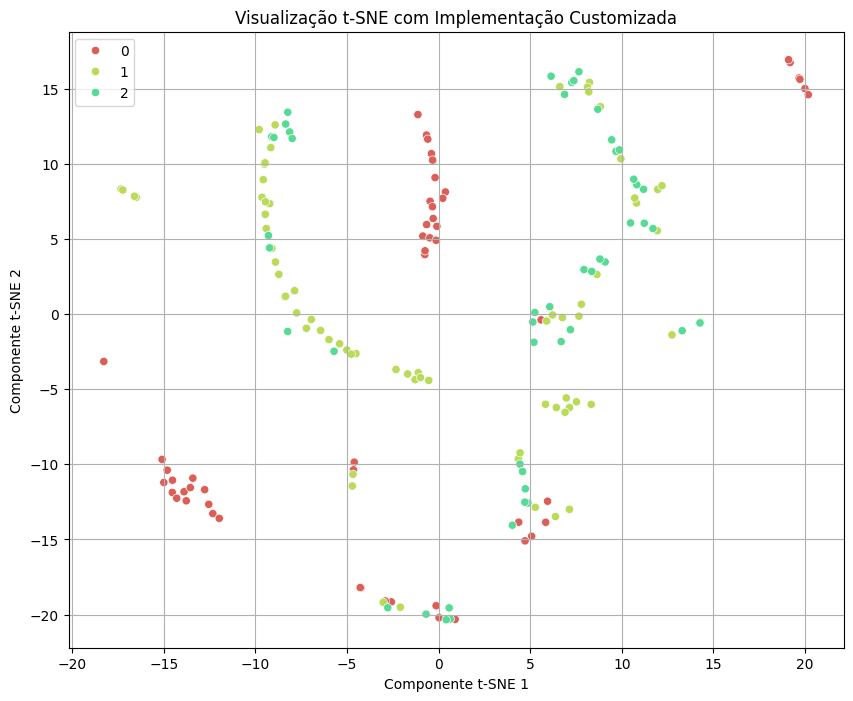

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 0.6425
Iter  200: cost = 0.5200
Iter  300: cost = 0.4612
Iter  400: cost = 0.4324
Iter  500: cost = 0.4133
Iter  600: cost = 0.3992
Iter  700: cost = 0.3884
Iter  800: cost = 0.3796
Iter  900: cost = 0.3722
Iter 1000: cost = 0.3659


/tmp/ipython-input-1483925130.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


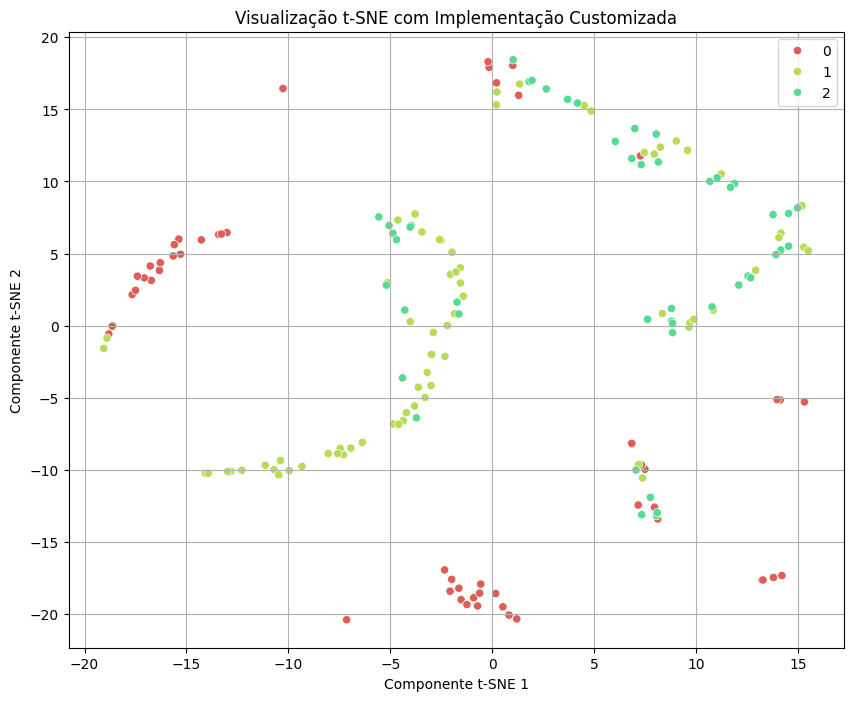

/tmp/ipython-input-26374851.py:32: RuntimeWarning: invalid value encountered in divide
  P_i /= np.sum(P_i)


Iter  100: cost = 0.7478
Iter  200: cost = 0.6325
Iter  300: cost = 0.5597
Iter  400: cost = 0.5239
Iter  500: cost = 0.4996
Iter  600: cost = 0.4772
Iter  700: cost = 0.4572
Iter  800: cost = 0.4465
Iter  900: cost = 0.4378
Iter 1000: cost = 0.4303


/tmp/ipython-input-1483925130.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


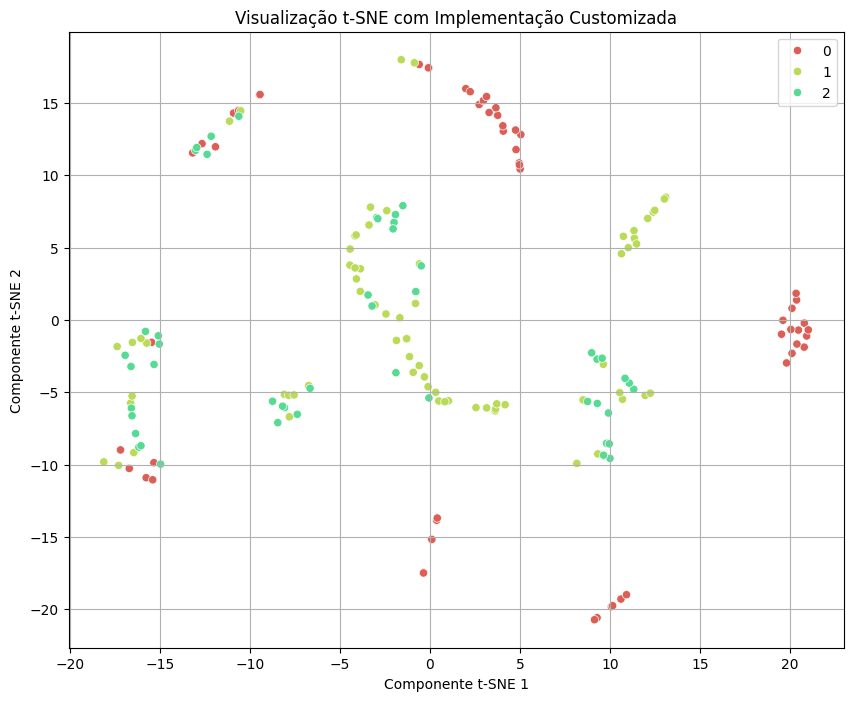

In [20]:
perplexi = [10.0, 30.0, 50.0, 70]
for i in perplexi:
    custom_tsne = TSNE(n_components=2, perplexity=10.0, n_iter=1000, lr=200)
    X_embedded_custom = custom_tsne.fit_transform(X)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_embedded_custom[:, 0],
        y=X_embedded_custom[:, 1],
        hue=y,
        palette=sns.color_palette("hls", n_clusters),
        legend="full"
    )
    plt.title('Visualização t-SNE com Implementação Customizada')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')
    plt.grid(True)
    plt.show()

tentativas com perplexidade valor 10, 30, 50, 70
não obtivemos um resultado satisfatório.